Phase 1 - Understanding the Dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('../notebooks/data/telco_churn.csv')

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 21)

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [24]:
# TotalCharges is string, convert to number
# errors='coerce' means if it finds something that can't be converted, make it NaN instead of crashing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN values appeared after conversion
print("TotalCharges nulls after fix:", df['TotalCharges'].isnull().sum())

# Fill those nulls with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Quick stats on numerical columns
df.describe()

TotalCharges nulls after fix: 11


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


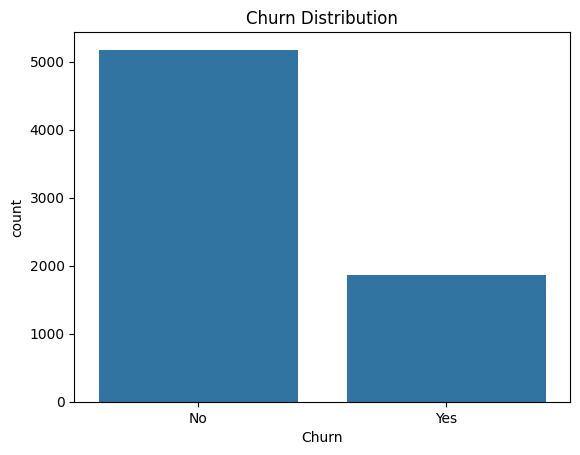

Churn Rate: 26.54 %


In [25]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print("Churn Rate:", round(df['Churn'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

Phase 2 - Preprocessing + Model Training

In [26]:
# Drop customerID - just an identifier, has no predictive value
# Drop the 11 rows where TotalCharges was null
df = df.drop(columns=['customerID'])
df = df.dropna(subset=['TotalCharges'])

# Convert Churn from Yes/No to 1/0 (Label Encoding)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Get all columns that are still text (object type)
categorical_cols = df.select_dtypes(include='str').columns.tolist()
print("Columns to encode:", categorical_cols)

# One Hot Encoding - converting each text column into relevant multiple 0/1 columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Churn value counts:", df['Churn'].value_counts())

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)
Churn value counts: Churn
0    5174
1    1869
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Separate features (X) and target (y)
# X = everything except Churn column AND y = Churn column
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split data into training set and test set (80% goes to training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Model trained successfully!
Training samples: 5634
Testing samples: 1409


In [28]:
# Run predictions on the test set
y_pred = model.predict(X_test)

# Classification report shows precision, recall, f1-score per class
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.66      0.45      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[951  85]
 [205 168]]


In [29]:
# Save the trained model as a .pkl file for FASTAPI's usage later
with open('../backend/models/churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the column names (needed in backend)
# so preprocessing produces columns in the exact same order the model expects
feature_columns = X.columns.tolist()
with open('../backend/models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Model saved successfully!")
print("Total features:", len(feature_columns))

Model saved successfully!
Total features: 30
